# Device measurements and static SNNs

The default flow shows each manuscript concept once. Device panels come from the measured fixtures, the primary architecture remains an immutable authored asset, and the static-network curves are produced by a fresh bounded `MSNN`/`MCSNN` run under `reduced` and `smoke`. The generated single-neuron SNN schematic is also shown by default. Set `MNN_SHOW_CONTEXT_FIGURES=1` only to inspect the remaining alternate thesis architecture and device views.

## Configuration and provenance

The controls below are shared across the release. `reduced` is CUDA-first and runs a small MNIST experiment; `smoke` uses a deterministic offline fixture. Neither profile writes figures unless explicitly requested. `publication` is the only profile that replays the committed long-run archive.

In [1]:
from pathlib import Path
from IPython.display import Image, display
import hashlib, json, os, shutil
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve()
if ROOT.name == "experiments":
    ROOT = ROOT.parent
NOTEBOOK_NAME = globals().get("NOTEBOOK_NAME", "01_device_and_static.ipynb")
RUN_PROFILE = os.getenv("MNN_RUN_PROFILE", "publication")  # reduced | publication | smoke
DEVICE = os.getenv("MNN_DEVICE", "auto")
WORKERS = os.getenv("MNN_WORKERS", "auto")
SAVE_FIGURES = os.getenv("MNN_SAVE_FIGURES", "0") == "1"
OUTPUT_DIR = Path(os.getenv("MNN_OUTPUT_DIR", str(ROOT / "experiments" / "generated_figures")))
OVERWRITE = os.getenv("MNN_OVERWRITE", "0") == "1"
RUN_EXTERNAL_DATA = os.getenv("MNN_RUN_EXTERNAL_DATA", "0") == "1"
ALLOW_DATA_DOWNLOADS = os.getenv("MNN_ALLOW_DATA_DOWNLOADS", "0") == "1"
SHOW_CONTEXT_FIGURES = os.getenv("MNN_SHOW_CONTEXT_FIGURES", "0") == "1"
GENERATE_STATIC_ARCHIVE = os.getenv("MNN_GENERATE_STATIC_ARCHIVE", "0") == "1"
STATIC_ARCHIVE_OUTPUT = Path(os.getenv("MNN_STATIC_ARCHIVE_OUTPUT", str(OUTPUT_DIR / "devicefixed_data.json")))
assert RUN_PROFILE in {"reduced", "publication", "smoke"}

try:
    import torch
    if DEVICE == "auto":
        DEVICE_RESOLVED = "cuda" if torch.cuda.is_available() else ("mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available() else "cpu")
    else:
        DEVICE_RESOLVED = DEVICE
except Exception:
    DEVICE_RESOLVED = "cpu"

MANIFEST = json.loads((ROOT / "experiments" / "figure_manifest.json").read_text())
SPEC = {row["filename"]: row for row in MANIFEST["figures"]}
FIGURE_REPORT = []
REFERENCE_DIR = ROOT / "experiments" / "assets" / "references"

def reference_path(name):
    return REFERENCE_DIR / name

def _hash(value):
    if value is None:
        return None
    if isinstance(value, Path):
        return hashlib.sha256(value.read_bytes()).hexdigest() if value.exists() else None
    payload = json.dumps(value, sort_keys=True, separators=(",", ":")).encode()
    return hashlib.sha256(payload).hexdigest()

def _guard_save(name, provenance):
    if provenance in {"placeholder", "reference-only", "external-gated"}:
        raise RuntimeError(f"Refusing to save non-claimable figure: {name}")
    if "manuscript" in str(OUTPUT_DIR).lower() and not OVERWRITE:
        raise RuntimeError("Writing into a manuscript directory requires MNN_OVERWRITE=1")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    target = OUTPUT_DIR / name
    if target.exists() and not OVERWRITE:
        raise FileExistsError(f"Refusing to overwrite {target}")
    return target

def finish(fig, name, data_source=None, reference=None, seeds=(),
           provenance_class=None, claim_status=None):
    spec = dict(SPEC[name])
    if provenance_class is not None:
        spec["provenance_class"] = provenance_class
    if claim_status is not None:
        spec["claim_status"] = claim_status
    display(fig)
    saved = None
    if SAVE_FIGURES:
        saved = _guard_save(name, spec["provenance_class"])
        fig.savefig(saved, dpi=300, bbox_inches="tight", facecolor="white")
    FIGURE_REPORT.append({
        **spec, "profile": RUN_PROFILE, "device": DEVICE_RESOLVED,
        "seeds": list(seeds), "data_sha256": _hash(data_source),
        "reference_sha256": _hash(reference), "saved_path": str(saved) if saved else None,
    })
    # Explicit display preserves order; closing prevents the inline backend
    # from rendering the still-open figure a second time at cell completion.
    plt.close(fig)
    return None

def record_skipped(name, reason):
    """Record an opt-in contextual figure without constructing or displaying it."""
    FIGURE_REPORT.append({**SPEC[name], "profile": RUN_PROFILE,
        "device": DEVICE_RESOLVED, "seeds": [], "data_sha256": None,
        "reference_sha256": _hash(reference_path(name)), "saved_path": None,
        "rendered": False, "skip_reason": reason})

def finish_asset(name, source):
    source = Path(source)
    display(Image(filename=str(source)))
    saved = None
    if SAVE_FIGURES:
        saved = _guard_save(name, SPEC[name]["provenance_class"])
        shutil.copyfile(source, saved)
    FIGURE_REPORT.append({**SPEC[name], "profile": RUN_PROFILE, "device": DEVICE_RESOLVED,
        "seeds": [], "data_sha256": _hash(source), "reference_sha256": _hash(source),
        "saved_path": str(saved) if saved else None})

def finish_reference(name, reference, expected_archive=None):
    reference = Path(reference)
    display(Image(filename=str(reference)))
    spec = SPEC[name]
    FIGURE_REPORT.append({**spec, "profile": RUN_PROFILE, "device": DEVICE_RESOLVED,
        "seeds": [], "data_sha256": _hash(expected_archive),
        "reference_sha256": _hash(reference), "saved_path": None})


## Measured device response

The manuscript device plot preserves the published loading order, filtering, colour scale, labels, limits, and layout. An alternate resistance/nonlinearity view is available with `MNN_SHOW_CONTEXT_FIGURES=1` and is hidden by default to avoid showing the same measurement twice.

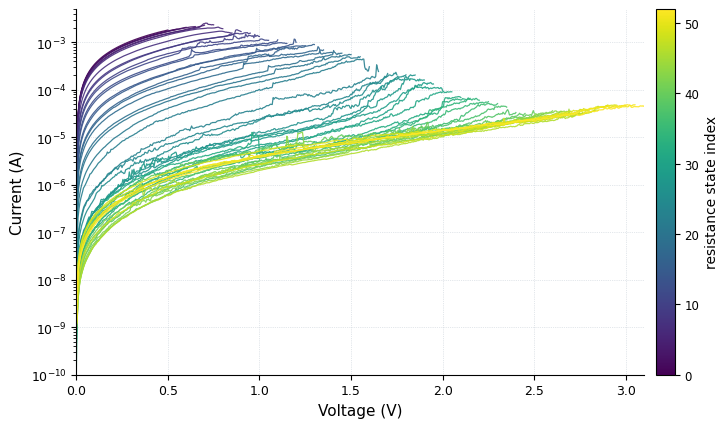

In [2]:
NOTEBOOK_NAME = "01_device_and_static.ipynb"

"""Regenerate Fig 6.6 (g.png): single sweeps of the 53 resistance states of a
SiOx device, recoloured in the publication green-blue (viridis) style for
stylistic consistency with Fig 6.8 (the subthreshold I-V sweeps of the SAME
device data).

Data: Notes/excelDataCombined.mat, which is byte-identical to
mnn-torch/data/SiO_x-multistate-data.mat (53 incremental-reset resistance states,
799 points, columns [current (A), voltage (V), resistance (ohm)]). The
flip/transpose loading idiom replicates gen_iv_sweeps.py so the curves match the
established figures; only the colourmap changes (rainbow -> viridis) and the 53
states are now coloured on a continuous resistance scale rather than a repeating
7-state cycle.

The states span maximum sweep voltages from 0.5 V (state 52, lowest resistance)
to 3.1 V (state 0, highest resistance), obtained by incrementing the maximum
voltage by 0.05 V between states.
"""
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

MAT = ROOT / "data" / "SiO_x-multistate-data.mat"


def load():
    """Return (voltages, currents, Rmean) for the 53 states.

    Replicates the gen_iv_sweeps.py / mnn_torch.devices loading order: data is
    [point, col, state] with col = (current, voltage, resistance); flip the state
    axis so index increases with sweep voltage, then transpose to [col, state,
    point]. Trailing NaN padding (sweeps have different lengths) is masked per
    curve at plot time.
    """
    d = sio.loadmat(MAT)["data"]            # (799, 3, 53) = [point, col, state]
    d = np.flip(d, axis=2)                   # ascending state order
    d = np.transpose(d, (1, 2, 0))           # [col, state, point]
    currents = d[0]                          # (state, point)
    voltages = d[1]
    resist = d[2]
    # mean resistance per state (finite, nonzero) -> used only for the colour scale
    Rmean = np.array([
        np.nanmean(np.where(np.isfinite(resist[s]) & (resist[s] > 0),
                            resist[s], np.nan))
        for s in range(resist.shape[0])
    ])
    return voltages, currents, Rmean


def clean_curve(v, i):
    """Drop the NaN padding and any non-positive current (for the log axis)."""
    m = np.isfinite(v) & np.isfinite(i) & (i > 0)
    return v[m], i[m]


V, I, Rmean = load()
n_state = V.shape[0]

# Continuous publication viridis scale by state index, which tracks
# the maximum sweep voltage / resistance ordering of the 53 states.
cmap = plt.cm.viridis
norm = Normalize(vmin=0, vmax=n_state - 1)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
for s in range(n_state):
    v, i = clean_curve(V[s], I[s])
    if v.size < 2:
        continue
    ax.plot(v, i, color=cmap(norm(s)), lw=0.9, alpha=0.9)

ax.set_yscale("log")
ax.set_xlabel("Voltage (V)", fontsize=11)
ax.set_ylabel("Current (A)", fontsize=11)
ax.set_xlim(0, 3.1)
ax.set_ylim(1e-10, 5e-3)
ax.tick_params(labelsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, which="major", ls=":", lw=0.5, color="#c8d0d8")

# colourbar: state index (proxy for resistance state)
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cb = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.046)
cb.set_label("resistance state index", fontsize=10)
cb.ax.tick_params(labelsize=8.5)

fig.tight_layout(pad=0.4)
finish(fig, "fig1_iv-sweeps.png", MAT, reference_path("fig1_iv-sweeps.png"))

"""Regenerate Fig 6.8: I-V sweeps of a SiOx device for two resistance regions,
recoloured in the publication green-blue (viridis) style for stylistic consistency.

Data: mnn-torch/data/SiO_x-multistate-data.mat (53 incremental-reset resistance
states, the same source used for the Poole-Frenkel parameterisation).
The loading/cleaning replicates mnn_torch.devices.load_SiOx_multistate +
load_SiOx_curves exactly, so the curves are identical to the original figure;
only the colourmap changes (inferno -> viridis) to match the device figures.

Panels: (a) low-resistance region, (b) high-resistance region, each curve coloured
by its mean nonlinearity gamma = I(0.5 V) / I(0.25 V) on a shared viridis scale.
"""
import os
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

MAT = ROOT / "data" / "SiO_x-multistate-data.mat"

MAX_V = 0.5
V_STEP = 0.005


def load():
    """Replicate mnn_torch.devices loading: returns (voltages, currents) arrays
    of shape (n_state, n_point), cleaned, over 0..0.5 V."""
    d = sio.loadmat(MAT)["data"]
    d = np.flip(d, axis=2)
    d = np.transpose(d, (1, 2, 0))      # [col, state, point]
    d = d[:2, :, :]
    npts = int(MAX_V / V_STEP) + 1
    d = d[:, :, :npts]
    # clean: drop curves whose 2nd-derivative/mean ratio exceeds 0.1 (noise)
    keep = []
    for i in range(d.shape[1]):
        c = d[0, i, :]
        r = np.gradient(np.gradient(c)) / np.mean(c)
        if r.max() < 0.1:
            keep.append(i)
    d = d[:, keep, :]
    return d[1], d[0]                   # voltages, currents  (state, point)


def nonlinearity(V, I):
    """Nonlinearity gamma = G(2 V_ref)/G(V_ref) with V_ref = 0.25 V (Ch6 Eq. 6.34),
    i.e. the conductance ratio G(0.5)/G(0.25) = 0.5 * I(0.5)/I(0.25). A value of 1
    is Ohmic; larger values indicate stronger I-V nonlinearity."""
    g = np.zeros(I.shape[0])
    for i in range(I.shape[0]):
        g_hi = np.interp(0.5, V[i], I[i]) / 0.5
        g_lo = np.interp(0.25, V[i], I[i]) / 0.25
        g[i] = g_hi / g_lo if g_lo != 0 else np.nan
    return g


V, I = load()
gamma = nonlinearity(V, I)
# split into low- vs high-resistance regions by current scale at 0.5 V
i_at_half = np.array([np.interp(0.5, V[i], I[i]) for i in range(I.shape[0])])
median_i = np.median(i_at_half)
low_idx = np.where(i_at_half >= median_i)[0]    # higher current = low resistance
high_idx = np.where(i_at_half < median_i)[0]

# shared viridis scale over gamma (publication green-blue palette)
gmin, gmax = np.nanmin(gamma), np.nanmax(gamma)
norm = Normalize(vmin=gmin, vmax=gmax)
cmap = plt.cm.viridis

fig, (axA, axB) = plt.subplots(1, 2, figsize=(7.2, 3.0))
for ax, idx, tag, scale in [
    (axA, low_idx, "(a)", 1e-3),
    (axB, high_idx, "(b)", 1e-6),
]:
    for i in idx:
        ax.plot(V[i], I[i] / scale, color=cmap(norm(gamma[i])), lw=1.0, alpha=0.9)
    ax.set_xlabel("Voltage (V)", fontsize=10)
    ax.set_xlim(0, 0.5)
    ax.set_title(tag, loc="left", fontsize=11, fontweight="bold")
    ax.set_ylabel(rf"Current ($\times10^{{{int(np.log10(scale))}}}$ A)", fontsize=10)
    ax.tick_params(labelsize=8.5)
    ax.spines[["top", "right"]].set_visible(False)

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cb = fig.colorbar(sm, ax=[axA, axB], fraction=0.046, pad=0.04)
cb.set_label("Mean nonlinearity", fontsize=10)
cb.ax.tick_params(labelsize=8.5)

if SHOW_CONTEXT_FIGURES:
    finish(fig, "fig_iv-nonlinearity.png", MAT, reference_path("fig_iv-nonlinearity.png"))
else:
    plt.close(fig)
    record_skipped("fig_iv-nonlinearity.png", "set MNN_SHOW_CONTEXT_FIGURES=1")


## Static-network architecture

The immutable manuscript architecture is displayed unchanged. Alternate architecture drawings remain executable for provenance, but are opt-in so the normal notebook presents one architecture figure.

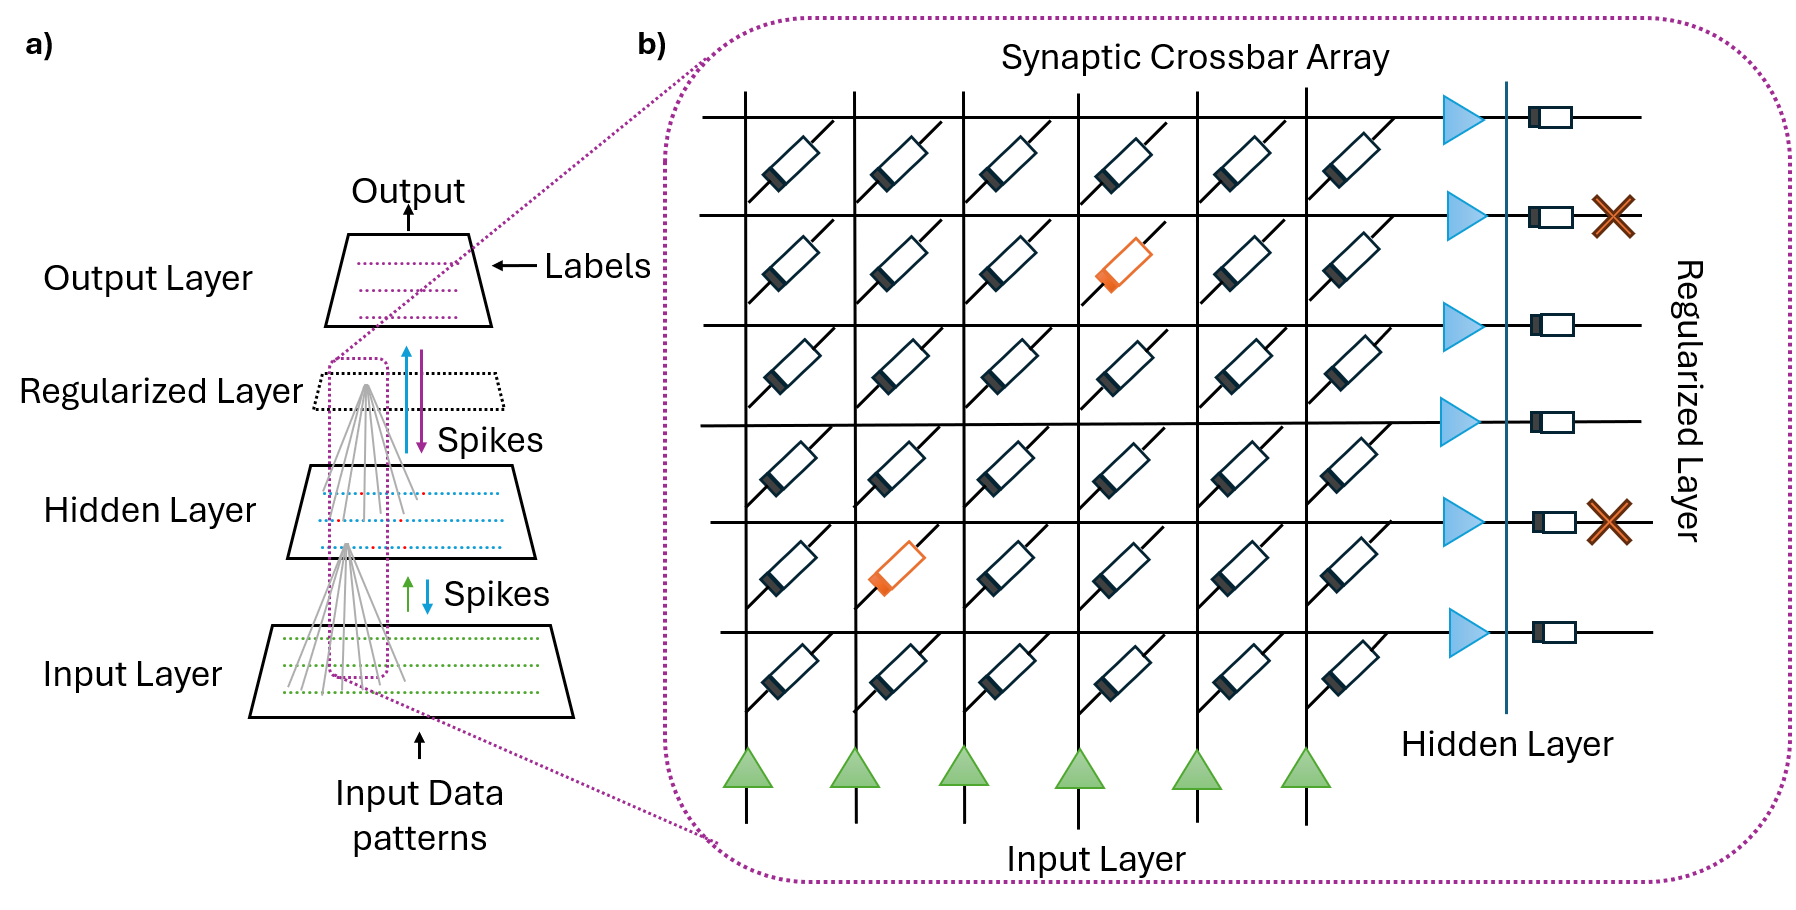

In [3]:
finish_asset("fig2_architecture.png", ROOT / "experiments" / "assets" / "architecture" / "fig2_architecture.png")

"""Regenerate Fig 6.8 (i.png): an abstract architecture schematic of the
memristive spiking neural network (MSNN) used for MNIST pattern recognition.

Redrawn cleanly in the publication green-blue palette (replacing the earlier
slide-style graphic) and corrected to the architecture described in the text:
a 28x28 MNIST image is flattened to a 784-dimensional rate-coded input, feeding a
SINGLE 100-unit memristive (crossbar) hidden layer of leaky integrate-and-fire
(LIF) neurons, then a 10-unit LIF output layer read out by a cross-entropy loss.
The hidden layer's synapses are a memristive crossbar (drawn as a small G-matrix
glyph), which is the feature the figure is meant to convey.

Palette: ideal/structure teal-green #3aa07a, memristive indigo #2f4b8f,
ink #2b2b2b, input amber-red spikes #c75c2e, on white at 300 dpi.
"""
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch, FancyBboxPatch, Rectangle


INK    = "#2b2b2b"
GREEN  = "#3aa07a"     # teal-green (structure / output)
MEMR   = "#2f4b8f"     # indigo (memristive hidden layer)
SPIKE  = "#c75c2e"     # input rate-coded spikes
GREY   = "#6f7680"
LGREY  = "#c8d0d8"

rng = np.random.default_rng(3)

fig, ax = plt.subplots(figsize=(7.4, 3.6))
ax.set_xlim(0, 12.2)
ax.set_ylim(0, 6.4)
ax.axis("off")


def arrow(p0, p1, color=INK, lw=1.2, ms=10, z=3, ls="-", alpha=1.0):
    ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle="-|>", mutation_scale=ms,
                 color=color, lw=lw, ls=ls, zorder=z, shrinkA=0, shrinkB=0,
                 alpha=alpha))


# ---------------- (1) input MNIST digit + flatten ----------------
# a small "7"-like MNIST glyph as a pixel grid
gx = np.linspace(0, 1, 12)
xx, yy = np.meshgrid(gx, gx)
img = np.zeros((12, 12))
img[2, 2:10] = 1.0                      # top stroke
for r in range(3, 11):                  # diagonal down-left
    c = int(9 - (r - 2) * 0.7)
    img[r, max(c, 1):c + 2] = 1.0
ax.imshow(img, cmap="gray_r", extent=(0.4, 1.9, 2.6, 4.1), zorder=3,
          interpolation="nearest")
ax.add_patch(Rectangle((0.4, 2.6), 1.5, 1.5, fill=False, edgecolor=INK,
             lw=1.2, zorder=4))
ax.text(1.15, 2.25, "input\n$28\\times28$", fontsize=8.5, ha="center", va="top",
        color=INK)

# rate-coded input spikes feeding the network
arrow((2.0, 3.35), (3.05, 3.35), color=SPIKE, lw=1.5, ms=11)
for xx0 in np.sort(rng.uniform(2.15, 2.9, 5)):
    ax.plot([xx0, xx0], [3.42, 3.62], color=SPIKE, lw=1.3, zorder=5,
            solid_capstyle="butt")
ax.text(2.5, 4.0, "flatten\n784", fontsize=8.0, ha="center", va="bottom",
        color=GREY, style="italic")


def neuron_column(x, n_draw, y_lo, y_hi, color, fill="white", r=0.16, z=5):
    ys = np.linspace(y_lo, y_hi, n_draw)
    for y in ys:
        ax.add_patch(Circle((x, y), r, facecolor=fill, edgecolor=color,
                     lw=1.4, zorder=z))
    return ys


# ---------------- (2) input layer (representative nodes) ----------------
xin = 3.4
yin = neuron_column(xin, 6, 1.2, 5.5, GREY, r=0.13)
# ellipsis to indicate 784
ax.text(xin, 0.85, "$\\vdots$", fontsize=11, ha="center", va="center", color=GREY)

# ---------------- (3) memristive hidden layer (crossbar) ----------------
xhid = 6.4
yhid = neuron_column(xhid, 5, 1.6, 5.1, MEMR, fill="#eaf0fb", r=0.17)
# dense connections input -> hidden, drawn faint
for y0 in yin:
    for y1 in yhid:
        ax.plot([xin + 0.13, xhid - 0.17], [y0, y1], color=MEMR, lw=0.35,
                alpha=0.30, zorder=2)
# memristive-crossbar glyph above the hidden column
cb_x, cb_y, cb_w, cb_h = 5.7, 5.45, 1.4, 0.75
ax.add_patch(FancyBboxPatch((cb_x, cb_y), cb_w, cb_h,
             boxstyle="round,pad=0.02,rounding_size=0.06",
             facecolor="#eaf0fb", edgecolor=MEMR, lw=1.2, zorder=4))
for i in range(4):
    ax.plot([cb_x + 0.15, cb_x + cb_w - 0.15],
            [cb_y + 0.18 + i * 0.13] * 2, color=MEMR, lw=0.8, zorder=5)
for j in range(5):
    ax.plot([cb_x + 0.2 + j * 0.25] * 2,
            [cb_y + 0.12, cb_y + cb_h - 0.1], color=GREEN, lw=0.8, zorder=5)
ax.text(cb_x + cb_w / 2, cb_y + cb_h + 0.12, "memristive crossbar $G_{ij}$",
        fontsize=7.8, ha="center", va="bottom", color=MEMR, style="italic")
ax.text(xhid, 0.95, "hidden\n100 LIF", fontsize=8.5, ha="center", va="top",
        color=MEMR, fontweight="bold")

# ---------------- (4) output layer ----------------
xout = 9.2
yout = neuron_column(xout, 10, 1.5, 5.2, GREEN, fill="#e7f4ee", r=0.135)
for y0 in yhid:
    for y1 in yout:
        ax.plot([xhid + 0.17, xout - 0.135], [y0, y1], color=GREEN, lw=0.35,
                alpha=0.28, zorder=2)
ax.text(xout, 0.95, "output\n10 LIF", fontsize=8.5, ha="center", va="top",
        color=GREEN, fontweight="bold")

# ---------------- (5) readout / cross-entropy ----------------
arrow((xout + 0.2, 3.35), (10.4, 3.35), color=INK, lw=1.4, ms=11)
ax.add_patch(FancyBboxPatch((10.45, 2.85), 1.45, 1.0,
             boxstyle="round,pad=0.02,rounding_size=0.08",
             facecolor="white", edgecolor=INK, lw=1.3, zorder=5))
ax.text(11.17, 3.35, "softmax\ncross-\nentropy", fontsize=7.8, ha="center",
        va="center", color=INK, linespacing=1.15, zorder=6)

# layer band labels along the top
ax.text(xin, 5.95, "input layer", fontsize=8.5, ha="center", color=GREY)
ax.text(xhid, 5.95, "", fontsize=8.5, ha="center")   # (crossbar glyph labels it)
ax.text(xout, 5.6, "output layer", fontsize=8.5, ha="center", color=GREEN)

if SHOW_CONTEXT_FIGURES:
    finish(fig, "fig_snn-arch.png", {"generator": "gen_i_msnn_arch", "seed": 3}, reference_path("fig_snn-arch.png"), seeds=[3])
else:
    plt.close(fig)
    record_skipped("fig_snn-arch.png", "set MNN_SHOW_CONTEXT_FIGURES=1")


## Live static MNIST training

For `reduced` and `smoke`, the curves below are generated during this notebook execution by the real `MSNN` and `MCSNN` classes. The reduced run uses a deterministic 512-example MNIST train/test subset, six epochs, and the publication model's ten simulation steps. It records actual loss and accuracy histories while remaining much smaller than the 6000/2000-example, three-seed publication sweep. These are validation curves, not substitutes for the full sweep. `publication` alone loads the documented long-run archive. Set `MNN_GENERATE_STATIC_ARCHIVE=1` only when an explicit run should also be written as JSON.

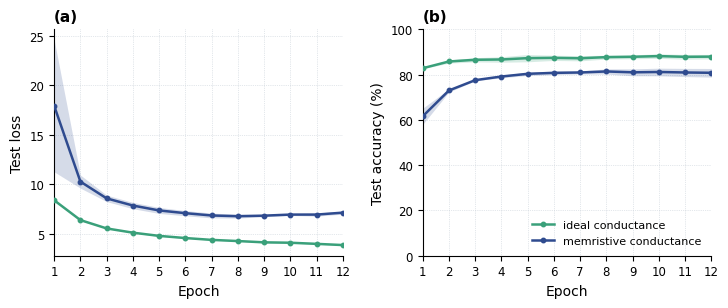

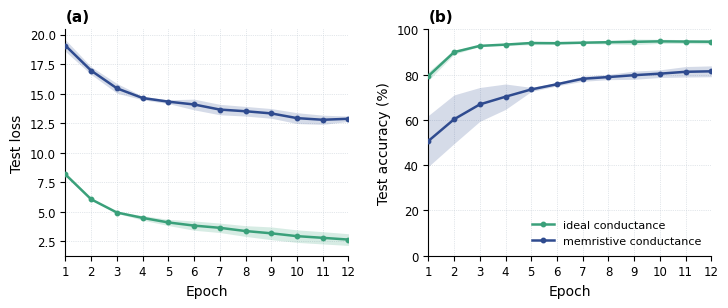

{'status': 'publication-archive-replay',
 'source': 'C:\\Users\\User\\git\\mnn-torch\\data\\devicefixed_data.json'}

In [4]:
"""Generate the static-network training panels from actual epoch histories.

Reduced and smoke execute bounded live MSNN/MCSNN experiments. Publication
replays the validated three-seed sweep because the full run is intentionally
outside the lightweight notebook path. No confidence interval or seed history
is synthesized from summary statistics.
"""
import os, json
import numpy as np
import matplotlib.pyplot as plt

DATA = ROOT / "data" / "devicefixed_data.json"

STATIC_BASE = {
    "beta": 0.95, "lr": 0.0005, "num_hidden": 100,
    "conv_kernels": 5, "conv1": 12, "conv2": 64, "max_pooling": 2,
    "disturb_probability": 0.5, "disturb_sigma_g": 0.5,
}
STATIC_CONDITIONS = {
    "ideal": "ideal=True",
    "memristive_pf": "nonlinear Poole-Frenkel I-V with frozen device variability",
    "fault": "memristive_pf plus fixed conductance disturbance",
}


def validate_static_archive(archive):
    """Reject incomplete, non-finite, or incorrectly shaped live/archive histories."""
    cfg = archive["config"]
    n_seed, n_epoch = len(cfg["seeds"]), int(cfg["epochs"])
    assert cfg["archs"] == ["fc", "conv"]
    conditions = tuple(cfg["conditions"])
    assert {"ideal", "memristive_pf"}.issubset(conditions)
    for arch in cfg["archs"]:
        for condition in conditions:
            node = archive[arch][condition]
            for metric in ("acc_hist", "loss_hist"):
                values = np.asarray(node[metric], dtype=float)
                assert values.shape == (n_seed, n_epoch), (arch, condition, metric, values.shape)
                assert np.isfinite(values).all()
    return archive


IDEAL = "#3aa07a"
MEMR = "#2f4b8f"
GRID = "#c8d0d8"


def stats(node, key):
    values = np.asarray(node[key], dtype=float)
    return values.mean(0), values.std(0)


def training_panel(ax, archive, arch_node, ylabel, kind):
    epochs = np.arange(1, int(archive["config"]["epochs"]) + 1)
    for cond, colour, label in [
        ("ideal", IDEAL, "ideal conductance"),
        ("memristive_pf", MEMR, "memristive conductance"),
    ]:
        mean, sd = stats(arch_node[cond], f"{kind}_hist")
        ax.plot(epochs, mean, color=colour, lw=1.8, marker="o", ms=3.2,
                label=label, zorder=4)
        if len(archive["config"]["seeds"]) > 1:
            ax.fill_between(epochs, mean - sd, mean + sd, color=colour,
                            alpha=0.20, lw=0, zorder=2)
    ax.set_xlabel("Epoch", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlim(1, max(2, int(archive["config"]["epochs"])))
    ax.set_xticks(epochs)
    ax.tick_params(labelsize=8.5)
    ax.grid(True, ls=":", lw=0.5, color=GRID)
    ax.spines[["top", "right"]].set_visible(False)


def make_training_figure(archive, arch, fname, data_source, provenance, claim):
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(7.2, 3.0))
    training_panel(axL, archive, archive[arch], "Test loss", "loss")
    training_panel(axR, archive, archive[arch], "Test accuracy (%)", "acc")
    axR.set_ylim(0, 100)
    axL.set_title("(a)", loc="left", fontsize=11, fontweight="bold")
    axR.set_title("(b)", loc="left", fontsize=11, fontweight="bold")
    legend_location = "lower right" if RUN_PROFILE == "publication" else "upper right"
    axR.legend(fontsize=8.0, frameon=False, loc=legend_location)
    fig.tight_layout(pad=0.4, w_pad=1.5)
    finish(fig, fname, data_source, reference_path(fname),
           seeds=archive["config"]["seeds"], provenance_class=provenance,
           claim_status=claim)


def _fixture_loaders(seed, batch_size):
    """Small deterministic offline fixture exercising both real model classes."""
    import torch
    from torch.utils.data import DataLoader, TensorDataset
    generator = torch.Generator().manual_seed(seed)
    labels = torch.arange(16) % 10
    images = torch.rand((16, 1, 28, 28), generator=generator)
    dataset = TensorDataset(images, labels)
    train = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True,
                       generator=torch.Generator().manual_seed(seed))
    test = DataLoader(dataset, batch_size=batch_size, shuffle=False, drop_last=True)
    return train, test


def static_generation_budget(profile):
    """Exact publication configuration plus bounded reduced/smoke variants."""
    base = dict(STATIC_BASE)
    if profile == "publication":
        # Exact committed archive contract; deliberately never launched implicitly.
        return {**base, "seeds": [0, 1, 2], "epochs": 12, "num_steps": 10,
                "batch_size": 64, "train_subset": 6000, "test_subset": 2000,
                "fixture": "MNIST"}
    if profile == "reduced":
        return {**base, "seeds": [0], "epochs": 6, "num_steps": 10,
                "batch_size": 64, "train_subset": 512, "test_subset": 512,
                "fixture": "MNIST"}
    return {**base, "seeds": [0], "epochs": 1, "num_steps": 1,
            "batch_size": 8, "train_subset": 16, "test_subset": 16,
            "conv1": 4, "conv2": 8, "fixture": "deterministic-offline"}


def _static_condition_config(condition, pf, budget):
    """Memristive config for the archive's three recorded conditions."""
    if condition == "ideal":
        return {"ideal": True}
    G_off, G_on, R, c, d_eps, slopes, intercepts, cov = pf
    config = {
        "ideal": False, "k_V": 0.5, "G_off": float(G_off), "G_on": float(G_on),
        "R": R, "c": c, "d_epsilon": d_eps, "nonlinear": True,
        "pf_slopes": slopes, "pf_intercepts": intercepts, "pf_covariance": cov,
        "pf_stochastic": True, "pf_frozen_variability": True,
        "homeostasis_dropout": False,
    }
    if condition == "memristive_pf":
        config["disturb_conductance"] = False
    elif condition == "fault":
        config.update(disturb_conductance=True, disturb_mode="device_fixed",
                      disturbance_probability=budget["disturb_probability"],
                      disturbance_sigma_g=budget["disturb_sigma_g"])
    else:
        raise ValueError(condition)
    return config


def _build_static_net(arch, condition, pf, budget, device):
    from snntorch import surrogate
    from mnn_torch.models import MSNN, MCSNN
    config = _static_condition_config(condition, pf, budget)
    if arch == "fc":
        return MSNN(28 * 28, budget["num_hidden"], 10,
                    num_steps=budget["num_steps"], beta=budget["beta"],
                    memristive_config=config).to(device)
    return MCSNN(
        beta=budget["beta"], spike_grad=surrogate.fast_sigmoid(slope=25),
        num_steps=budget["num_steps"], batch_size=budget["batch_size"],
        num_kernels=budget["conv_kernels"], num_conv1=budget["conv1"],
        num_conv2=budget["conv2"], max_pooling=budget["max_pooling"],
        num_outputs=10, memristive_config=config,
    ).to(device)


def _static_forward(net, arch, images):
    output = net(images.view(images.shape[0], -1)) if arch == "fc" else net(images)
    return output[0], output[1]


def _move_static(batch, device):
    return batch.to(device, non_blocking=(device.type == "cuda"))


def _evaluate_static(net, arch, loader, device, loss_fn, num_steps):
    import torch
    net.eval(); correct = total = batches = 0; loss_sum = 0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = _move_static(images, device), _move_static(labels, device)
            spikes, membrane = _static_forward(net, arch, images)
            loss_sum += sum(loss_fn(membrane[t], labels) for t in range(num_steps)).item()
            correct += (spikes.sum(0).argmax(1) == labels).sum().item()
            total += labels.shape[0]; batches += 1
    return 100.0 * correct / total, loss_sum / batches


def _train_static_arm(arch, condition, pf, seed, budget, device, loader_factory):
    """Canonical per-seed training loop; returns both recorded epoch histories."""
    import torch
    import torch.nn as nn
    torch.manual_seed(seed); np.random.seed(seed)
    train_loader, test_loader = loader_factory(seed)
    net = _build_static_net(arch, condition, pf, budget, device)
    optimizer = torch.optim.Adam(net.parameters(), lr=budget["lr"])
    loss_fn = nn.CrossEntropyLoss()
    acc_hist, loss_hist = [], []
    for _ in range(budget["epochs"]):
        net.train()
        for images, labels in train_loader:
            images, labels = _move_static(images, device), _move_static(labels, device)
            _, membrane = _static_forward(net, arch, images)
            loss = sum(loss_fn(membrane[t], labels) for t in range(budget["num_steps"]))
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        accuracy, test_loss = _evaluate_static(
            net, arch, test_loader, device, loss_fn, budget["num_steps"])
        acc_hist.append(accuracy); loss_hist.append(test_loss)
    return {"acc_hist": acc_hist, "loss_hist": loss_hist}


def generate_static_archive(profile=RUN_PROFILE, output_path=None):
    """Train FC+conv ? ideal+PF+fixed-fault and return the documented archive schema.

    `publication` exactly matches the committed 3-seed/12-epoch/6000+2000 budget.
    Call it explicitly: the notebook's publication replay never starts that sweep.
    """
    import time
    import torch
    from mnn_torch.data import ensure_mnist, mnist_loaders
    from mnn_torch.training import precompute_device_params

    budget = static_generation_budget(profile)
    device = torch.device(DEVICE_RESOLVED)
    pf = precompute_device_params(ROOT / "data")
    if budget["fixture"] == "deterministic-offline":
        loader_factory = lambda seed: _fixture_loaders(seed, budget["batch_size"])
    else:
        data_root = ROOT / "data"
        if not (data_root / "MNIST" / "raw").exists():
            if not ALLOW_DATA_DOWNLOADS:
                raise FileNotFoundError("MNIST absent; set MNN_ALLOW_DATA_DOWNLOADS=1")
            ensure_mnist(data_root)
        loader_factory = lambda seed: mnist_loaders(
            data_root, seed=seed, batch_size=budget["batch_size"],
            train_subset=budget["train_subset"], test_subset=budget["test_subset"],
            num_workers=0, pin_memory=(device.type == "cuda"))

    config = {key: budget[key] for key in (
        "seeds", "epochs", "num_steps", "beta", "lr", "batch_size",
        "train_subset", "test_subset", "num_hidden", "conv_kernels", "conv1",
        "conv2", "max_pooling", "disturb_probability", "disturb_sigma_g")}
    conditions = STATIC_CONDITIONS if profile == "publication" else {
        key: STATIC_CONDITIONS[key] for key in ("ideal", "memristive_pf")}
    config.update(device=str(device), archs=["fc", "conv"], conditions=conditions)
    result = {"config": config}; started = time.time()
    for arch in config["archs"]:
        result[arch] = {}
        for condition in config["conditions"]:
            rows = [_train_static_arm(arch, condition, pf, seed, budget, device,
                                      loader_factory) for seed in config["seeds"]]
            result[arch][condition] = {
                "acc_hist": [row["acc_hist"] for row in rows],
                "loss_hist": [row["loss_hist"] for row in rows],
            }
    result["wall_seconds"] = time.time() - started
    validate_static_archive(result)

    if output_path is not None:
        target = Path(output_path)
        if target.resolve() == DATA.resolve() and not OVERWRITE:
            raise RuntimeError("Refusing to overwrite the committed archive without MNN_OVERWRITE=1")
        target.parent.mkdir(parents=True, exist_ok=True)
        if target.exists() and not OVERWRITE:
            raise FileExistsError(target)
        target.write_text(json.dumps(result, indent=2))
    return result


if RUN_PROFILE == "publication" and not GENERATE_STATIC_ARCHIVE:
    # Publication replay is the sole normal consumer of the costly archived sweep.
    PLOT_ARCHIVE = validate_static_archive(json.loads(DATA.read_text()))
    PLOT_SOURCE = DATA
    PLOT_PROVENANCE = "published-sample-archive"
    PLOT_CLAIM = "claimable"
    LIVE_GENERATION = {"status": "publication-archive-replay", "source": str(DATA)}
else:
    # Reduced and smoke always plot fresh in-memory histories from real model forwards.
    output = STATIC_ARCHIVE_OUTPUT if GENERATE_STATIC_ARCHIVE else None
    PLOT_ARCHIVE = generate_static_archive(RUN_PROFILE, output)
    PLOT_SOURCE = PLOT_ARCHIVE
    PLOT_PROVENANCE = "live-reduced"
    PLOT_CLAIM = "reduced-validation"
    LIVE_GENERATION = {
        "status": "completed-live", "profile": RUN_PROFILE,
        "output": str(output) if output else None,
        "wall_seconds": PLOT_ARCHIVE["wall_seconds"],
        "samples": {"train": PLOT_ARCHIVE["config"]["train_subset"],
                    "test": PLOT_ARCHIVE["config"]["test_subset"]},
    }

make_training_figure(PLOT_ARCHIVE, "fc", "fig3_msnn-training.png",
                     PLOT_SOURCE, PLOT_PROVENANCE, PLOT_CLAIM)
make_training_figure(PLOT_ARCHIVE, "conv", "fig4_mcsnn-training.png",
                     PLOT_SOURCE, PLOT_PROVENANCE, PLOT_CLAIM)
LIVE_GENERATION


## Single-neuron dynamics

The deterministic LIF generator is part of the default reading flow. Its membrane trace is integrated from the same weighted input spikes drawn in the structural panel, so the schematic is generated rather than replayed as an image asset.

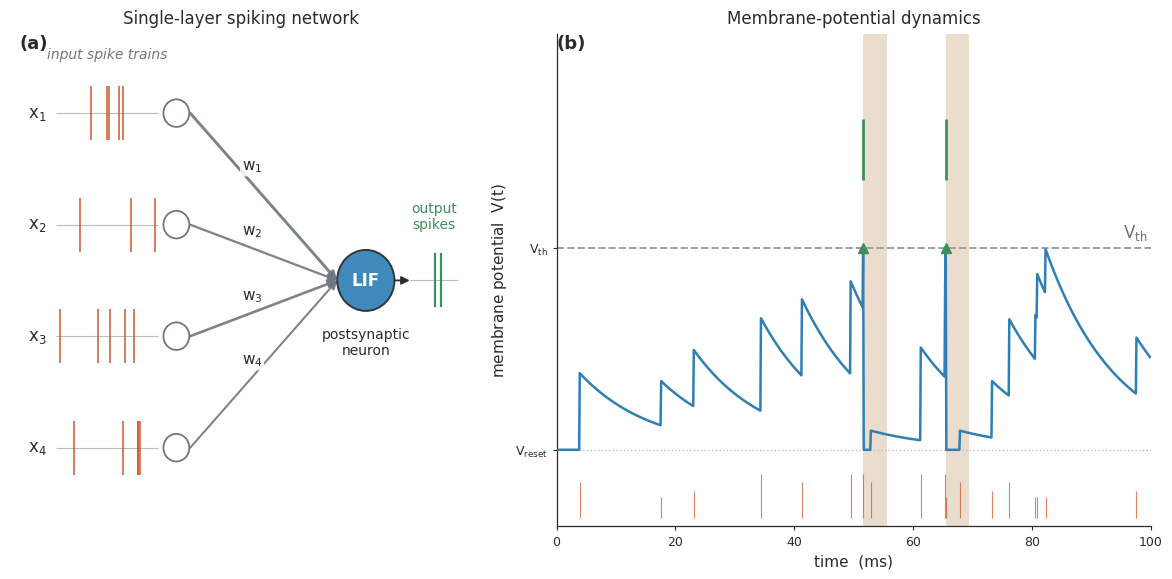

In [5]:
"""
Original schematic of a single-layer spiking neural network (SNN).

Two logically connected panels:
  (left)  n presynaptic neurons emit Poisson-like spike trains x_1..x_n, each
          weighted by a synaptic efficacy w_i and converging on one postsynaptic
          leaky-integrate-and-fire (LIF) neuron, which emits an output spike train.
  (right) The membrane-potential trajectory V(t) of that postsynaptic neuron,
          showing leaky integration between inputs, upward jumps at weighted input
          spikes, a dashed firing threshold V_th, reset and an emitted output spike
          at threshold crossings, and a shaded refractory window during which the
          input drive is attenuated.

PROVENANCE / HONESTY:
  The V(t) trace is NOT hand-drawn. It is produced by an actual forward-Euler LIF
  integration of the exact same weighted input spikes drawn on the left panel:
      tau * dV/dt = -V + sum_i w_i * x_i(t)
  with hard reset to V_reset on threshold crossing and a refractory window in which
  the input drive is scaled down. A fixed RNG seed makes the figure reproducible.

Output: snn_schematic_new.png (300 dpi), saved alongside this script.
"""
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle, Rectangle


# ----------------------------------------------------------------------------
# Muted, greyscale-friendly thesis palette
# ----------------------------------------------------------------------------
INK     = "#2b2b2b"   # primary lines / text
GREY    = "#6f7680"   # secondary
LGREY   = "#b8bdc4"   # light fills / inactive
ACCENT  = "#2f7fb5"   # membrane / postsynaptic neuron (blue)
SPIKE   = "#c75c2e"   # input spikes (amber-red)
OUTSPK  = "#3f8f5b"   # output spikes (green)
REFRAC  = "#d9c2a6"   # refractory shading (warm tan)
THRESH  = "#9aa0a6"   # threshold line

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.linewidth": 0.9,
    "mathtext.default": "regular",
})

# ----------------------------------------------------------------------------
# 1. Generate weighted input spike trains (shared by BOTH panels)
# ----------------------------------------------------------------------------
rng = np.random.default_rng(20260616)

N_IN = 4                       # number of presynaptic neurons
T = 100.0                      # total time (ms)
dt = 0.1                       # integration step (ms)
t = np.arange(0.0, T, dt)
nt = t.size

# Per-synapse firing rates (Hz) and weights (a.u.). Tuned so the postsynaptic
# neuron fires only a handful of times across T, leaving clear inter-spike
# segments in which the leaky integration (and refractory window) are visible.
rates_hz = np.array([32.0, 20.0, 38.0, 16.0])      # presynaptic rates
weights  = np.array([0.46, 0.28, 0.38, 0.22])      # w_1..w_n synaptic efficacies

# Bernoulli (Poisson-approx) spike trains, one row per presynaptic neuron.
spike_trains = np.zeros((N_IN, nt), dtype=bool)
for i in range(N_IN):
    p = rates_hz[i] * (dt / 1000.0)                # spike prob per step
    spike_trains[i] = rng.random(nt) < p

# Weighted total synaptic drive into the postsynaptic neuron at each step.
drive = (weights[:, None] * spike_trains).sum(axis=0)

# ----------------------------------------------------------------------------
# 2. ACTUAL LIF simulation (forward Euler) -> membrane trajectory V(t)
#       tau dV/dt = -V + I(t),  hard reset, refractory drive attenuation
# ----------------------------------------------------------------------------
tau = 12.0          # membrane time constant (ms)  -> visible leak
V_th = 1.0          # firing threshold
V_reset = 0.0       # reset potential
t_ref = 4.0         # refractory period (ms)
ref_gain = 0.25     # input effectiveness during refractory (reduced effect)

V = np.zeros(nt)
v = V_reset
ref_until = -1.0                 # time index until which neuron is refractory
out_spike_times = []
ref_windows = []                 # (start_t, end_t) shaded later

for k in range(nt):
    in_ref = t[k] < ref_until
    gain = ref_gain if in_ref else 1.0
    # forward-Euler leaky integration with (possibly attenuated) input drive
    dV = (-v / tau) * dt + gain * drive[k]
    v = v + dV
    if v >= V_th:
        V[k] = V_th              # draw the crossing at threshold
        out_spike_times.append(t[k])
        ref_windows.append((t[k], t[k] + t_ref))
        v = V_reset              # hard reset
        ref_until = t[k] + t_ref
    else:
        V[k] = v

out_spike_times = np.array(out_spike_times)

# ----------------------------------------------------------------------------
# 3. Figure layout: left structural schematic | right temporal dynamics
# ----------------------------------------------------------------------------
fig = plt.figure(figsize=(12.2, 6.0))
gs = fig.add_gridspec(1, 2, width_ratios=[1.05, 1.35], wspace=0.16,
                      left=0.04, right=0.975, top=0.92, bottom=0.10)

# =========================== LEFT: network structure ========================
axL = fig.add_subplot(gs[0, 0])
axL.set_xlim(0, 10)
axL.set_ylim(0, 10)
axL.axis("off")
axL.set_title("Single-layer spiking network", fontsize=12, pad=8, color=INK)

# Geometry
x_label = 0.4          # x for x_i labels
x_train = 1.0          # left edge of mini spike trains
x_train_w = 2.2        # width of mini spike trains
x_pre = 3.6            # presynaptic node x
x_post = 7.7           # postsynaptic neuron x
y_pre = np.linspace(8.4, 1.6, N_IN)   # top-to-bottom so x_1 is on top
y_post = 5.0
train_h = 0.55         # half-height of mini spike trains

# Draw each presynaptic neuron: mini spike train + node + weighted synapse
for i in range(N_IN):
    yi = y_pre[i]
    # --- mini input spike train (subset of the real spike train) ---
    st = t[spike_trains[i]]
    st = st[st <= T]
    sx = x_train + (st / T) * x_train_w
    axL.hlines(yi, x_train, x_train + x_train_w, color=LGREY, lw=0.8, zorder=1)
    axL.vlines(sx, yi - train_h, yi + train_h, color=SPIKE, lw=1.1, zorder=2)
    # x_i label
    axL.text(x_label, yi, rf"$x_{{{i+1}}}$", fontsize=12, color=INK,
             ha="left", va="center")
    # presynaptic node
    axL.add_patch(Circle((x_pre, yi), 0.28, facecolor="white",
                         edgecolor=GREY, lw=1.3, zorder=3))
    # --- weighted synaptic connection to postsynaptic neuron ---
    lw = 0.9 + 2.6 * weights[i]      # line thickness encodes weight magnitude
    arr = FancyArrowPatch((x_pre + 0.30, yi), (x_post - 0.62, y_post),
                          arrowstyle="-|>", mutation_scale=12,
                          lw=lw, color=GREY, alpha=0.9,
                          shrinkA=0, shrinkB=0, zorder=2)
    axL.add_patch(arr)
    # weight label placed along the synapse
    fx, fy = 0.42, 0.42            # fractional position along the line
    wx = (x_pre + 0.30) + fx * ((x_post - 0.62) - (x_pre + 0.30))
    wy = yi + fy * (y_post - yi)
    axL.text(wx, wy + 0.18, rf"$w_{{{i+1}}}$", fontsize=11, color=INK,
             ha="center", va="bottom",
             bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.85))

axL.text(x_train + x_train_w / 2, y_pre[0] + 1.05, "input spike trains",
         fontsize=10, color=GREY, ha="center", va="bottom", style="italic")

# --- postsynaptic LIF neuron ---
axL.add_patch(Circle((x_post, y_post), 0.62, facecolor=ACCENT,
                     edgecolor=INK, lw=1.4, alpha=0.92, zorder=4))
axL.text(x_post, y_post, "LIF", color="white", fontsize=12, fontweight="bold",
         ha="center", va="center", zorder=5)
axL.text(x_post, y_post - 0.95, "postsynaptic\nneuron", fontsize=10, color=INK,
         ha="center", va="top")

# --- output spike train emitted from the neuron ---
x_out0, x_outw = x_post + 0.95, 1.05
axL.hlines(y_post, x_out0, x_out0 + x_outw, color=LGREY, lw=0.8, zorder=1)
arr = FancyArrowPatch((x_post + 0.62, y_post), (x_out0, y_post),
                      arrowstyle="-|>", mutation_scale=12, lw=1.3,
                      color=INK, shrinkA=0, shrinkB=0, zorder=3)
axL.add_patch(arr)
ox = x_out0 + (out_spike_times / T) * x_outw
axL.vlines(ox, y_post - train_h, y_post + train_h, color=OUTSPK, lw=1.6, zorder=4)
axL.text(x_out0 + x_outw / 2, y_post + 1.0, "output\nspikes", fontsize=10,
         color=OUTSPK, ha="center", va="bottom")

# panel tag
axL.text(0.02, 1.0, "(a)", transform=axL.transAxes, fontsize=13,
         fontweight="bold", color=INK, ha="left", va="top")

# =========================== RIGHT: membrane dynamics =======================
axR = fig.add_subplot(gs[0, 1])
axR.set_title("Membrane-potential dynamics", fontsize=12, pad=8, color=INK)

# shaded refractory windows (drawn first, behind everything)
for (rs, re) in ref_windows:
    axR.axvspan(rs, re, color=REFRAC, alpha=0.55, lw=0, zorder=0)

# threshold line
axR.axhline(V_th, color=THRESH, ls="--", lw=1.4, zorder=2)
axR.text(T * 0.995, V_th + 0.03, r"$V_{th}$", color="#6b6f74",
         fontsize=12, ha="right", va="bottom")
# reset / rest line
axR.axhline(V_reset, color=LGREY, ls=":", lw=1.0, zorder=1)

# membrane trajectory (the real LIF output)
axR.plot(t, V, color=ACCENT, lw=1.8, zorder=4, solid_capstyle="round")

# input-spike rug at the bottom: tick marks where weighted inputs arrive,
# tick height encodes the weighted contribution (visualises "weighted jumps").
rug_base = -0.34
rug_scale = 0.22
for i in range(N_IN):
    st = t[spike_trains[i]]
    h = rug_scale * (weights[i] / weights.max())
    axR.vlines(st, rug_base, rug_base + h, color=SPIKE, lw=0.8, alpha=0.75, zorder=3)

# output spikes at top: full-height markers at threshold crossings
out_y = V_th + 0.34
for ts in out_spike_times:
    axR.vlines(ts, out_y, out_y + 0.30, color=OUTSPK, lw=2.0, zorder=5)
    axR.plot(ts, V_th, marker="^", color=OUTSPK, ms=7, zorder=6, clip_on=False)

# (Panel (b) text annotations and their pointing arrows -- "weighted input
# spikes", "output spike", "weighted input jump", "leaky integration" and the
# refractory-period callout -- were removed at the author's request; the trace,
# threshold/reset lines, spike rug and output markers carry the panel on their own.)

# axis cosmetics
axR.set_xlim(0, T)
axR.set_ylim(rug_base - 0.04, out_y + 0.72)
axR.set_xlabel("time  (ms)", fontsize=11, color=INK)
axR.set_ylabel(r"membrane potential  $V(t)$", fontsize=11, color=INK)
axR.spines["top"].set_visible(False)
axR.spines["right"].set_visible(False)
axR.spines["left"].set_color(INK)
axR.spines["bottom"].set_color(INK)
axR.set_yticks([V_reset, V_th])
axR.set_yticklabels([r"$V_{reset}$", r"$V_{th}$"], fontsize=10)
axR.tick_params(axis="both", labelsize=9, colors=INK, length=3)

axR.text(0.0, 1.0, "(b)", transform=axR.transAxes, fontsize=13,
         fontweight="bold", color=INK, ha="left", va="top")

# ----------------------------------------------------------------------------
finish(fig, "snn_schematic.png",
       {"generator": "gen_snn_schematic", "seed": 20260616, "dt_ms": dt},
       reference_path("snn_schematic.png"), seeds=[20260616])


## Reproduction report

The in-memory report records the profile, resolved device, seeds, hashes, provenance class, and claim status. It is available without writing any image.

In [6]:
assert len(FIGURE_REPORT) == len([x for x in MANIFEST["figures"] if x["notebook"] == Path(globals().get("NOTEBOOK_NAME", "")).name])
FIGURE_REPORT

[{'filename': 'fig1_iv-sweeps.png',
  'tier': 'main',
  'notebook': '01_device_and_static.ipynb',
  'profile': 'publication',
  'device': 'cuda',
  'seeds': [],
  'data_hash': 'a07035682c4310988dedb697ebfcb5a302e447aaffb89309ba1a99812189ddf6',
  'reference_hash': 'cb52821094e07ed840a13111484e25c00297bed04f1dea0797bafd69642576c3',
  'provenance_class': 'live-exact',
  'claim_status': 'claimable',
  'data_sha256': 'a07035682c4310988dedb697ebfcb5a302e447aaffb89309ba1a99812189ddf6',
  'reference_sha256': 'cb52821094e07ed840a13111484e25c00297bed04f1dea0797bafd69642576c3',
  'saved_path': None},
 {'filename': 'fig_iv-nonlinearity.png',
  'tier': 'context',
  'notebook': '01_device_and_static.ipynb',
  'profile': 'publication',
  'device': 'cuda',
  'seeds': [],
  'data_hash': 'a07035682c4310988dedb697ebfcb5a302e447aaffb89309ba1a99812189ddf6',
  'reference_hash': '7d873513faccf2b74b810276673bc0657d973cbf411dc25a79929a3e2644f12a',
  'provenance_class': 'live-exact',
  'claim_status': 'claimabl